# Discount Prediction on Electronics Products: Comprehensive Modeling Pipeline

## Table of Contents

1. [Data Loading and Preprocessing](#1-data-loading-and-preprocessing)
2. [Category Cleaning and Mapping](#2-category-cleaning-and-mapping)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
    - 3.1 [Dataset Overview](#31-dataset-overview)
    - 3.2 [Missing Values and Outliers](#32-missing-values-and-outliers)
    - 3.3 [Date Parsing and Temporal Features](#33-date-parsing-and-temporal-features)
    - 3.4 [Discount Distribution Analysis](#34-discount-distribution-analysis)
    - 3.5 [Temporal Pattern Analysis](#35-temporal-pattern-analysis)
    - 3.6 [Correlation and Heatmaps](#36-correlation-and-heatmaps)
4. [Stationarity Tests](#4-stationarity-tests)
    - 4.1 [ADF Test](#41-adf-test)
    - 4.2 [KPSS Test](#42-kpss-test)
    - 4.3 [Seasonal Tests (CH and OCSB)](#43-seasonal-tests-ch-and-ocsb)
5. [ACF and PACF Analysis](#5-acf-and-pacf-analysis)
6. [Lag Feature Analysis](#6-lag-feature-analysis)
7. [Feature Engineering](#7-feature-engineering)
    - 7.1 [Time Features](#71-time-features)
    - 7.2 [Price Tiers and Quarters](#72-price-tiers-and-quarters)
8. [Train/Test Split](#8-traintest-split)
9. [Two-Stage Model: Classification + Regression](#9-two-stage-model-classification--regression)
    - 9.1 [Stage 1: Discount Detection (Logistic Regression)](#91-stage-1-discount-detection-logistic-regression)
    - 9.2 [Stage 2: Discount Amount Prediction (SARIMAX)](#92-stage-2-discount-amount-prediction-sarimax)
10. [ARIMA Model with Grid Search](#10-arima-model-with-grid-search)
11. [SARIMA Model with Grid Search](#11-sarima-model-with-grid-search)
12. [Model Evaluation and Comparison](#12-model-evaluation-and-comparison)
13. [MLflow Tracking](#13-mlflow-tracking)
14. [Conclusion](#14-conclusion)

---


# 1. Data Loading and Preprocessing

This section imports the required libraries and loads the Electronics Products Pricing dataset.
The dataset contains product pricing information scraped from multiple e-commerce platforms over the period 2014--2018.

**Dataset**: `ElectronicsProductsPricingData.csv`

**Key Variables**:
- `prices.amountMax`: Listed (regular) price
- `prices.amountMin`: Sale/current price
- `prices.dateSeen`: Date the price observation was recorded
- `categories`: Product category hierarchy
- `id`: Unique product identifier

We compute a **discount percentage** variable $y$ as:

$$ y = \frac{\text{amountMax} - \text{amountMin}}{\text{amountMax}} \times 100 $$

This serves as our primary target variable for both classification (is there a discount?) and regression (how deep is the discount?).

**Primary Libraries used**:
- `pandas`, `numpy` for data manipulation
- `matplotlib`, `seaborn` for visualization
- `statsmodels` for time series analysis (ARIMA, SARIMAX, ADF, ACF/PACF)
- `scikit-learn`, `imbalanced-learn` for machine learning
- `mlflow` for experiment tracking


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mlflow
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    f1_score, classification_report
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from scripts.cleaning_categories import clean_and_map_categories

# ── Configuration ──
MLFLOW_TRACKING_URI = "http://86.50.20.250/"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("All libraries imported successfully.")


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


In [2]:
# ── Load Dataset ──
df = pd.read_csv("./ElectronicsProductsPricingData.csv", encoding='latin1')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)


Dataset shape: (7249, 31)
Columns: ['id', 'prices.amountMax', 'prices.amountMin', 'prices.availability', 'prices.condition', 'prices.currency', 'prices.dateSeen', 'prices.isSale', 'prices.merchant', 'prices.shipping', 'prices.sourceURLs', 'asins', 'brand', 'categories', 'dateAdded', 'dateUpdated', 'ean', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'primaryCategories', 'sourceURLs', 'upc', 'weight', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30']


,id,prices.amountMax,prices.amountMin,prices.availability,prices.condition,prices.currency,prices.dateSeen,prices.isSale,prices.merchant,prices.shipping,...,name,primaryCategories,sourceURLs,upc,weight,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,AVphzgbJLJeJML43fA0o,104.99,104.99,Yes,New,USD,"2017-03-30T06:00:00Z,2017-03-10T22:00:00Z,2017...",False,Bestbuy.com,NaN,...,Sanus VLF410B1 10-Inch Super Slim Full-Motion ...,Electronics,https://www.amazon.com/Sanus-VLF410B1-10-Inch-...,7.94E+11,32.8 pounds,NaN,NaN,NaN,NaN,NaN
1,AVpgMuGwLJeJML43KY_c,69.00,64.99,In Stock,New,USD,2017-12-14T06:00:00Z,True,Walmart.com,Expedited,...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,NaN,NaN,NaN,NaN,NaN
2,AVpgMuGwLJeJML43KY_c,69.00,69.00,In Stock,New,USD,2017-09-08T05:00:00Z,False,Walmart.com,Expedited,...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── Compute Discount Percentage (target variable y) ──
df['y'] = np.where(
    df['prices.amountMax'] > 0,
    100 * (df['prices.amountMax'] - df['prices.amountMin']) / df['prices.amountMax'],
    0
)

# ── Convert date column ──
df["prices.dateSeen"] = pd.to_datetime(df["prices.dateSeen"], errors='coerce')
df = df.rename(columns={"prices.dateSeen": "date"})

# ── Clean up unnecessary columns ──
cols_to_drop = [
    "Unnamed: 26", "Unnamed: 27", "Unnamed: 28", "Unnamed: 29", "Unnamed: 30",
    "sourceURLs", "prices.currency", "keys", "ean", "prices.shipping",
    "manufacturerNumber", "upc"
]
existing_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing_drop, inplace=True, errors='ignore')

print(f"Shape after cleanup: {df.shape}")
df[["y", "prices.amountMax", "date", "prices.amountMin"]].head()


Shape after cleanup: (7249, 20)


/var/folders/st/r78_rxtx0hd_yr_r8qtl08_c0000gn/T/ipykernel_84416/2851433790.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["prices.dateSeen"] = pd.to_datetime(df["prices.dateSeen"], errors='coerce')


,y,prices.amountMax,date,prices.amountMin
0,0.000000,104.99,NaT,104.99
1,5.811594,69.00,2017-12-14 06:00:00+00:00,64.99
2,0.000000,69.00,2017-09-08 05:00:00+00:00,69.00
3,0.000000,69.99,2017-10-10 05:00:00+00:00,69.99
4,0.000000,66.99,2017-08-28 07:00:00+00:00,66.99


# 2. Category Cleaning and Mapping

Product categories are provided as comma-separated strings with inconsistent naming.
We use a dedicated script `cleaning_categories.py` that:

1. **Normalizes** category strings (lowercase, strip whitespace)
2. **Maps** variant names to standard categories (e.g., "laptops", "pc laptops" → "computers")
3. **Removes** noise (short tokens, garbage characters)
4. **Deduplicates** the resulting category list

The **main category** (first element of the cleaned list) is extracted for aggregation.

**Standardized categories include**: `computers`, `storage`, `tv_video`, `mobile`, `camera`, `audio` and others.


In [4]:
# ── Apply category cleaning ──
df["clean_categories"] = df["categories"].apply(clean_and_map_categories)

# ── Extract main category ──
def get_main_category(cat_list):
    return cat_list[0] if len(cat_list) > 0 else "unknown"

df["main_category"] = df["clean_categories"].apply(get_main_category)

# ── String version for plotting ──
df["clean_categories_str"] = df["clean_categories"].apply(lambda x: " | ".join(x))

print("Main category distribution:")
print(df["main_category"].value_counts())


Main category distribution:
main_category
computers                       2010
audio                            813
tv_video                         776
electronics                      680
camera                           417
                                ... 
android auto receivers             2
turntables & accessories           2
a/v surge protectors & power       2
powered subwoofers                 2
smart watches                      2
Name: count, Length: 108, dtype: int64


# 3. Exploratory Data Analysis (EDA)

Comprehensive visualizations to understand pricing patterns, discount trends, and temporal relationships.
This section addresses the deep EDA milestone to justify the transition to predictive modeling.


## 3.1 Dataset Overview

We inspect the dataset structure, data types, and basic statistics to understand data quality.


In [5]:
# ── Dataset Info ──
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7249 entries, 0 to 7248
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   id                    7249 non-null   object             
 1   prices.amountMax      7249 non-null   float64            
 2   prices.amountMin      7249 non-null   float64            
 3   prices.availability   7249 non-null   object             
 4   prices.condition      7249 non-null   object             
 5   date                  3674 non-null   datetime64[ns, UTC]
 6   prices.isSale         7249 non-null   bool               
 7   prices.merchant       7249 non-null   object             
 8   prices.sourceURLs     7249 non-null   object             
 9   asins                 7249 non-null   object             
 10  brand                 7249 non-null   object             
 11  categories            7249 non-null   object             
 12  dateAd

In [6]:
# ── Statistical Summary ──
df[["prices.amountMax", "prices.amountMin", "y"]].describe()


,prices.amountMax,prices.amountMin,y
count,7249.000000,7249.000000,7249.000000
mean,495.530610,463.963005,2.654130
std,763.599387,680.504507,9.631336
min,1.000000,1.000000,0.000000
25%,79.990000,79.950000,0.000000
50%,198.990000,189.990000,0.000000
75%,494.990000,479.990000,0.000000
max,6999.990000,5999.990000,80.003200


In [7]:
# ── Product ID Distribution ──
value_counts = df["id"].value_counts()
print(f"Unique products: {len(value_counts)}")
print(f"Top 10 most frequently observed products:")
print(value_counts.head(10))


Unique products: 835
Top 10 most frequently observed products:
id
AV1YFZVDvKc47QAVgp7V    59
AVs4jJ0Vnnc1JgDc4w40    53
AVrI3KE1U2_QcyX9O9Iw    52
AVzxqGmivKc47QAVfTIA    45
AVqkH8TtU2_QcyX9O0rJ    45
AVwjdOdov8e3D1O-nnK9    44
AVzSv0q-vKc47QAVd60B    42
AVqkEzW9U2_QcyX9O0Gr    42
AV1YDsmoGV-KLJ3adcbe    39
AV1YHofqglJLPUi8IGyn    39
Name: count, dtype: int64


## 3.2 Missing Values and Outliers

We check for missing values and detect outliers using the Z-score method
(values beyond 3 standard deviations from the mean).


In [8]:
# ── Missing Values ──
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("Columns with missing values:")
    print(missing)
else:
    print("No missing values found.")


Columns with missing values:
date            3575
manufacturer    4014
dtype: int64


Detected 263 outliers (y > 31.55 or y < -26.24)


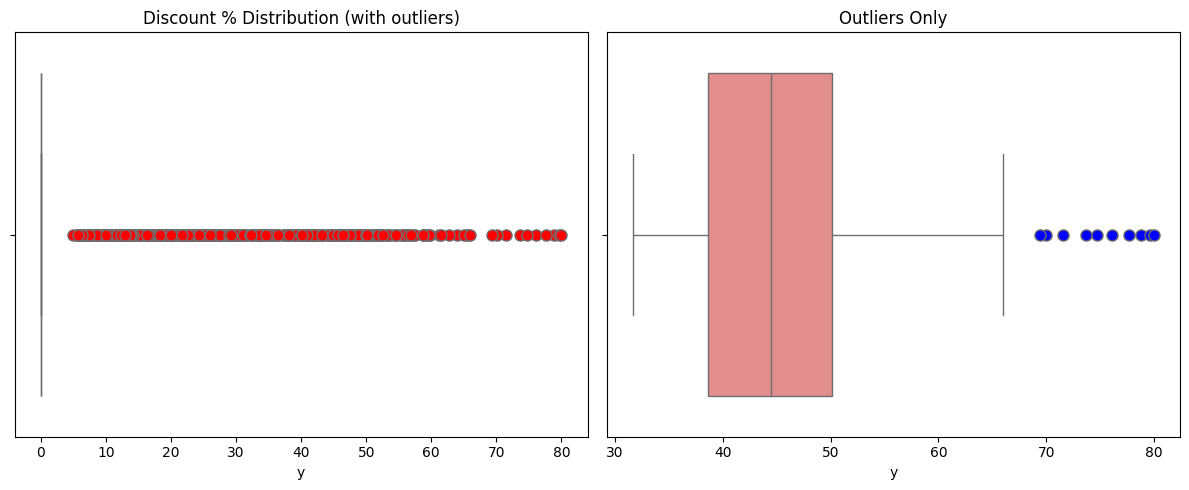

In [9]:
# ── Outlier Detection (Z-score method) ──
mean_y = df['y'].mean()
std_y = df['y'].std()
upper_limit = mean_y + (3 * std_y)
lower_limit = mean_y - (3 * std_y)

outliers = df[(df['y'] > upper_limit) | (df['y'] < lower_limit)]
print(f"Detected {len(outliers)} outliers (y > {upper_limit:.2f} or y < {lower_limit:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['y'], color='skyblue', ax=axes[0],
            flierprops={'markerfacecolor': 'red', 'markersize': 8})
axes[0].set_title("Discount % Distribution (with outliers)")

sns.boxplot(x=outliers['y'], color='lightcoral', ax=axes[1],
            flierprops={'markerfacecolor': 'blue', 'markersize': 8})
axes[1].set_title("Outliers Only")
plt.tight_layout()
plt.show()


## 3.3 Date Parsing and Temporal Features

Proper date handling is crucial for time series analysis.
We convert string dates to datetime objects and filter to the high-density period 2017--2018.


In [10]:
# ── Year distribution before filtering ──
print("Year distribution of date column:")
print(df["date"].dt.year.value_counts().sort_index())

# ── Filter to 2017 (train) and 2018 (test) ──
df_2018 = df[df["date"].dt.year == 2018].copy()
df = df[df["date"].dt.year == 2017].copy()

print(f"\nTrain (2017) rows: {len(df)}")
print(f"Test  (2018) rows: {len(df_2018)}")


Year distribution of date column:
date
2014.0      11
2015.0      59
2017.0    2250
2018.0    1354
Name: count, dtype: int64

Train (2017) rows: 2250
Test  (2018) rows: 1354


## 3.4 Discount Distribution Analysis

Understanding the distribution of discount percentages is critical.
The data is heavily **zero-inflated** (most observations have no discount), which motivates our **two-stage modeling approach**:

| Stage | Goal | Model Type | Output |
|-------|------|------------|--------|
| **Stage 1** | Does this product have a discount? | Classification (Logistic Regression) | Yes/No (binary) |
| **Stage 2** | How deep is the discount? | Regression (SARIMAX) | Discount % (continuous) |

This architectural decision minimizes error caused by zero-inflated target variables.


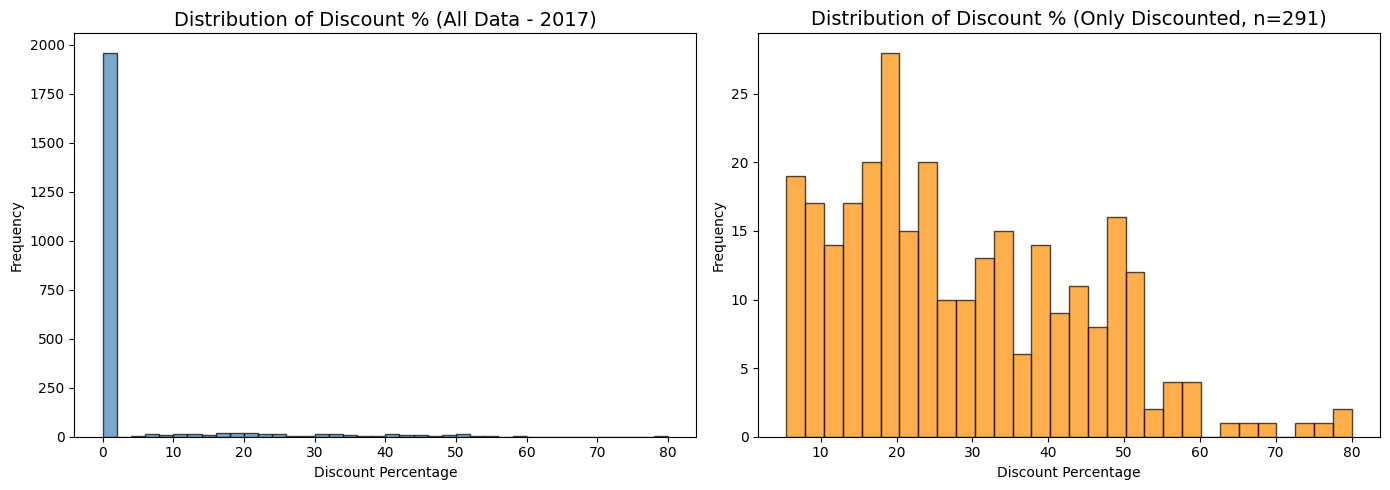

Zero discount observations: 87.07%
Non-zero discount observations: 12.93%


In [11]:
# ── Discount Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df["y"], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Discount % (All Data - 2017)", fontsize=14)
axes[0].set_xlabel("Discount Percentage")
axes[0].set_ylabel("Frequency")

# Non-zero only
nonzero = df[df["y"] > 0]["y"]
axes[1].hist(nonzero, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title(f"Distribution of Discount % (Only Discounted, n={len(nonzero)})", fontsize=14)
axes[1].set_xlabel("Discount Percentage")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("./images/discount_distribution.png")
plt.show()

zero_pct = (df["y"] == 0).sum() / len(df) * 100
print(f"Zero discount observations: {zero_pct:.2f}%")
print(f"Non-zero discount observations: {100 - zero_pct:.2f}%")


## 3.5 Temporal Pattern Analysis

We analyze discount patterns across multiple temporal dimensions.
This helps identify **seasonality** and **promotional cycles**.

Key hypotheses:
- **Thursday effect**: Retailers often re-price on Thursdays ahead of weekend shopping
- **Q4 spike**: Holiday season (Black Friday, Christmas) drives deeper discounts
- **Price tier behavior**: Higher-priced items may see different discount patterns


In [12]:
# ── Engineer temporal features ──
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

df_2018['day_of_week'] = df_2018['date'].dt.dayofweek
df_2018['month'] = df_2018['date'].dt.month
df_2018['week_of_year'] = df_2018['date'].dt.isocalendar().week.astype(int)

# Binary Thursday flag
df['is_thursday'] = (df['day_of_week'] == 3).astype(int)
df_2018['is_thursday'] = (df_2018['day_of_week'] == 3).astype(int)

# Quarter
df["quarter"] = df["month"].apply(lambda x: (x - 1) // 3 + 1)
df_2018["quarter"] = df_2018["month"].apply(lambda x: (x - 1) // 3 + 1)

# Price tiers
df["price_tier"] = pd.cut(
    df["prices.amountMin"],
    bins=[0, 50, 100, 200, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium']
)
df_2018["price_tier"] = pd.cut(
    df_2018["prices.amountMin"],
    bins=[0, 50, 100, 200, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium']
)

print("Time features engineered.")
df[['date', 'day_of_week', 'week_of_year', 'is_thursday']].head()


Time features engineered.


,date,day_of_week,week_of_year,is_thursday
1,2017-12-14 06:00:00+00:00,3,50,1
2,2017-09-08 05:00:00+00:00,4,36,0
3,2017-10-10 05:00:00+00:00,1,41,0
4,2017-08-28 07:00:00+00:00,0,35,0
5,2017-10-24 04:00:00+00:00,1,43,0


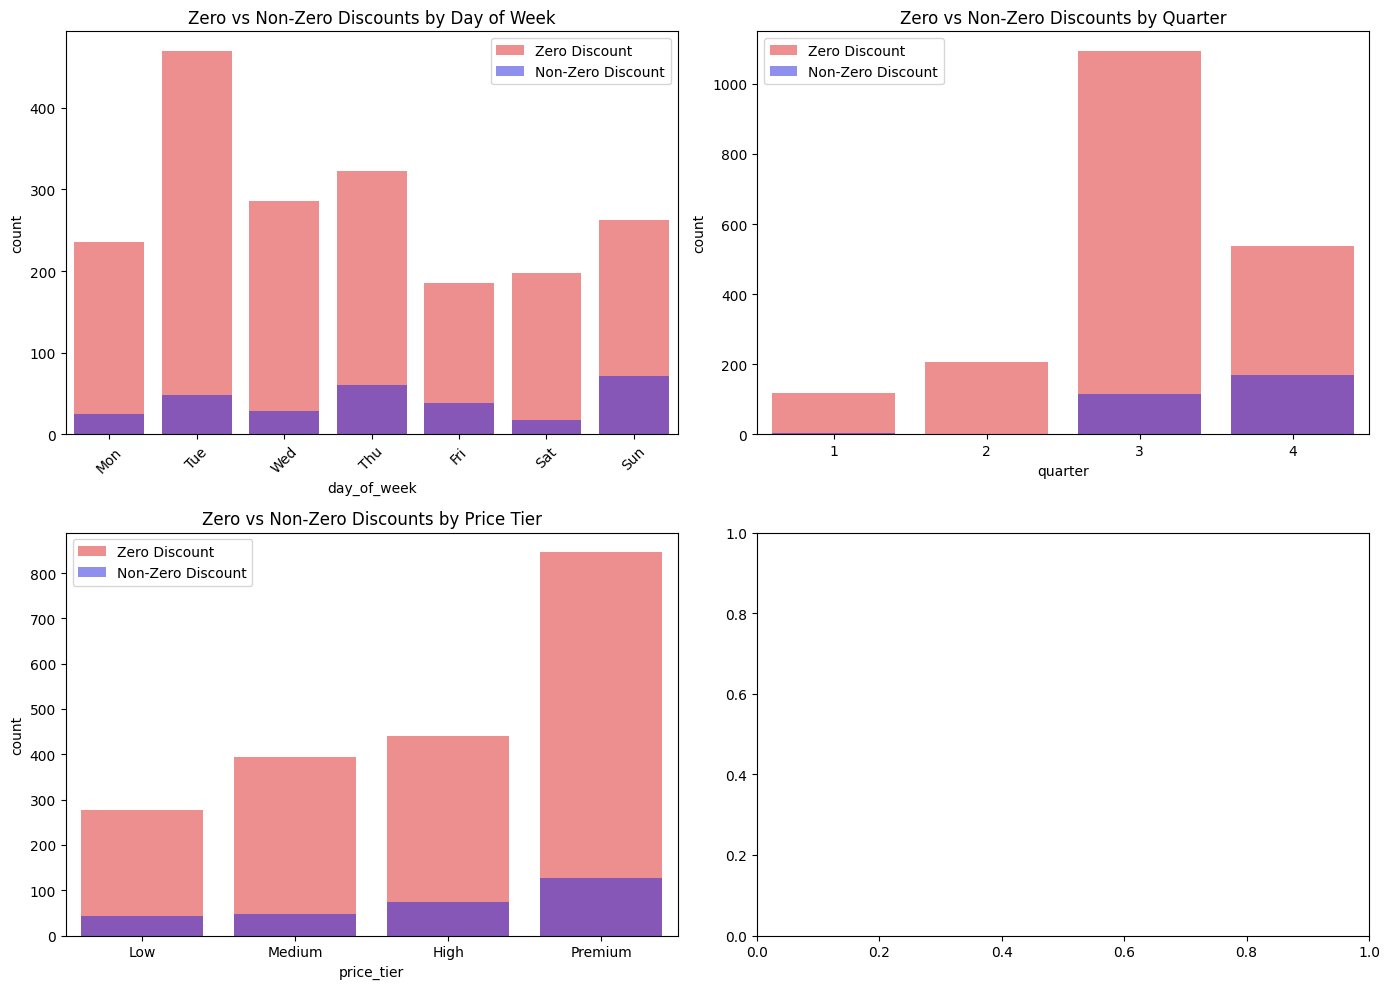

In [13]:
# ── Discount by Day of Week, Quarter, Price Tier ──
zero_count = df[df["y"] == 0]
non_zero_count = df[df["y"] > 0]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Day of week
sns.countplot(x=zero_count['day_of_week'], color='red', alpha=0.5,
              label='Zero Discount', ax=axes[0, 0])
sns.countplot(x=non_zero_count['day_of_week'], color='blue', alpha=0.5,
              label='Non-Zero Discount', ax=axes[0, 0])
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(weekdays, rotation=45)
axes[0, 0].set_title('Zero vs Non-Zero Discounts by Day of Week')
axes[0, 0].legend()

# Quarter
sns.countplot(x=zero_count['quarter'], color='red', alpha=0.5,
              label='Zero Discount', ax=axes[0, 1])
sns.countplot(x=non_zero_count['quarter'], color='blue', alpha=0.5,
              label='Non-Zero Discount', ax=axes[0, 1])
axes[0, 1].set_title('Zero vs Non-Zero Discounts by Quarter')
axes[0, 1].legend()

# Price tier
sns.countplot(x=zero_count['price_tier'], color='red', alpha=0.5,
              label='Zero Discount', ax=axes[1, 0])
sns.countplot(x=non_zero_count['price_tier'], color='blue', alpha=0.5,
              label='Non-Zero Discount', ax=axes[1, 0])
axes[1, 0].set_title('Zero vs Non-Zero Discounts by Price Tier')
axes[1, 0].legend()
plt.tight_layout()
plt.show()


/var/folders/st/r78_rxtx0hd_yr_r8qtl08_c0000gn/T/ipykernel_84416/4198873675.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(weekdays_full, rotation=45)


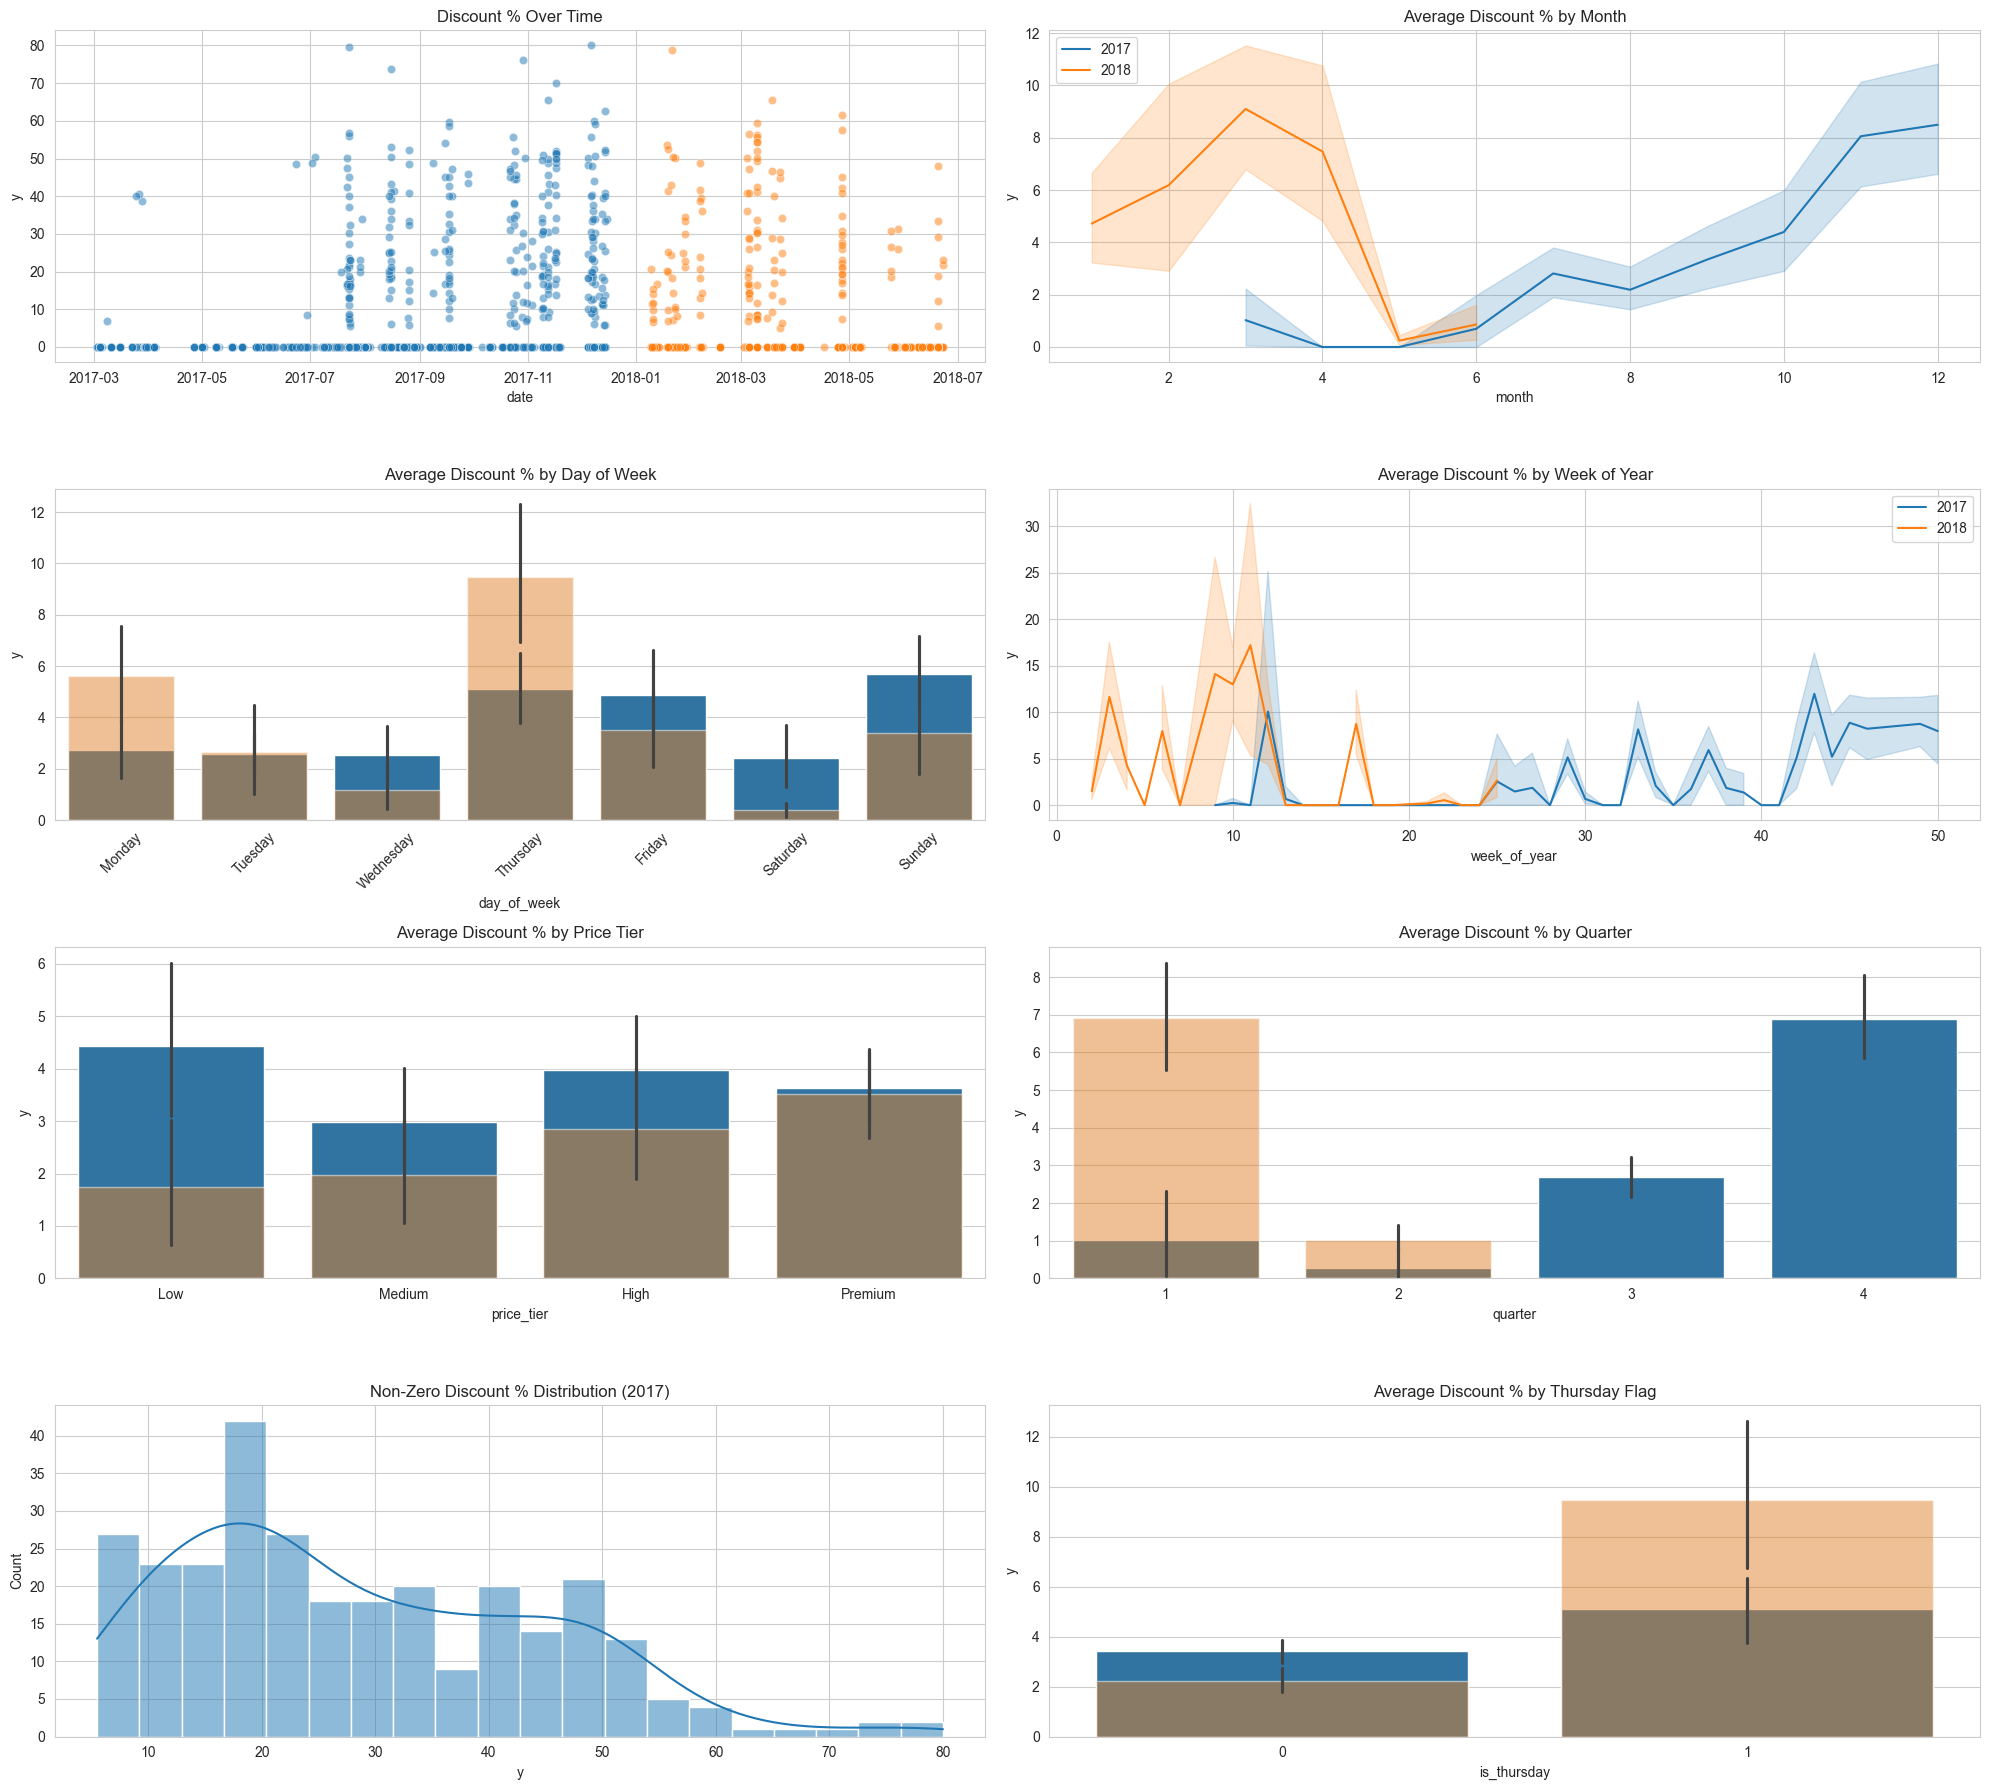

In [14]:
# ── Comprehensive EDA Visualization Matrix ──
np.random.seed(42)
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 18))
axes = axes.flatten()

# 1. Scatter: date vs y
sns.scatterplot(data=df, x="date", y="y", ax=axes[0], alpha=0.5)
sns.scatterplot(data=df_2018, x="date", y="y", ax=axes[0], alpha=0.5)
axes[0].set_title("Discount % Over Time")

# 2. Line: month vs y
sns.lineplot(data=df, x="month", y="y", ax=axes[1], label="2017")
sns.lineplot(data=df_2018, x="month", y="y", ax=axes[1], label="2018")
axes[1].set_title("Average Discount % by Month")

# 3. Bar: day_of_week vs y
weekdays_full = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(data=df, x="day_of_week", y="y", ax=axes[2], order=range(7))
sns.barplot(data=df_2018, x="day_of_week", y="y", ax=axes[2], order=range(7), alpha=0.5)
axes[2].set_xticklabels(weekdays_full, rotation=45)
axes[2].set_title("Average Discount % by Day of Week")

# 4. Line: week_of_year vs y
sns.lineplot(data=df, x="week_of_year", y="y", ax=axes[3], label="2017")
sns.lineplot(data=df_2018, x="week_of_year", y="y", ax=axes[3], label="2018")
axes[3].set_title("Average Discount % by Week of Year")

# 5. Bar: price_tier vs y
sns.barplot(data=df, x="price_tier", y="y", ax=axes[4])
sns.barplot(data=df_2018, x="price_tier", y="y", ax=axes[4], alpha=0.5)
axes[4].set_title("Average Discount % by Price Tier")

# 6. Bar: quarter vs y
sns.barplot(data=df, x="quarter", y="y", ax=axes[5])
sns.barplot(data=df_2018, x="quarter", y="y", ax=axes[5], alpha=0.5)
axes[5].set_title("Average Discount % by Quarter")

# 7. Non-zero discount distribution
sns.histplot(data=df[df["y"] > 0], x="y", ax=axes[6], bins=20, kde=True)
axes[6].set_title("Non-Zero Discount % Distribution (2017)")

# 8. Bar: is_thursday vs y
sns.barplot(data=df, x="is_thursday", y="y", ax=axes[7])
sns.barplot(data=df_2018, x="is_thursday", y="y", ax=axes[7], alpha=0.5)
axes[7].set_title("Average Discount % by Thursday Flag")

plt.tight_layout()
plt.show()


## 3.6 Correlation and Heatmaps

Heatmaps provide a color-coded view of discount patterns across months and years, making seasonal trends immediately visible.


Monthly average discount %:
year       2017      2018
month                    
1           NaN  4.718250
2           NaN  6.187096
3      1.026038  9.100015
4      0.000000  7.473789
5      0.000000  0.243359
6      0.695997  0.860670
7      2.811128       NaN
8      2.188683       NaN
9      3.339386       NaN
10     4.397000       NaN
11     8.056822       NaN
12     8.496878       NaN


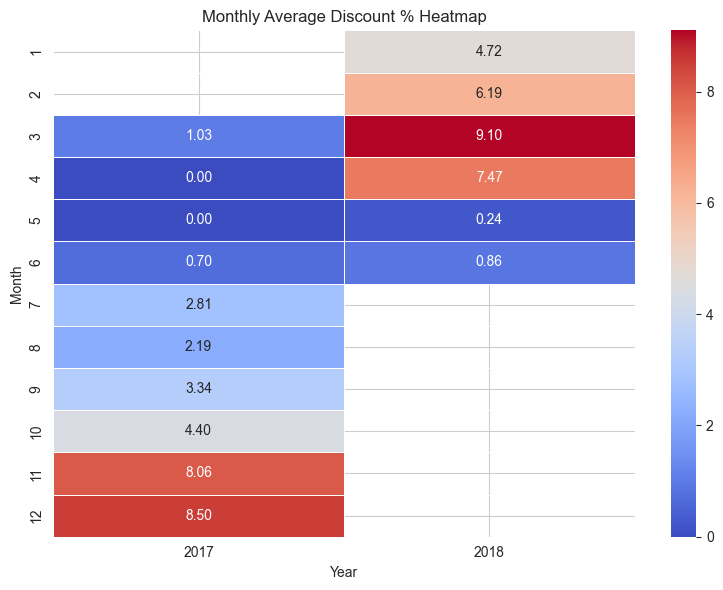

In [15]:
# ── Month x Year Pivot Table ──
df_all = pd.concat([df.assign(year=2017), df_2018.assign(year=2018)])
pivot = df_all.pivot_table(
    values="y", index=df_all["month"],
    columns=df_all["year"], aggfunc="mean"
)
print("Monthly average discount %:")
print(pivot)

# ── Heatmap ──
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Monthly Average Discount % Heatmap")
plt.ylabel("Month")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


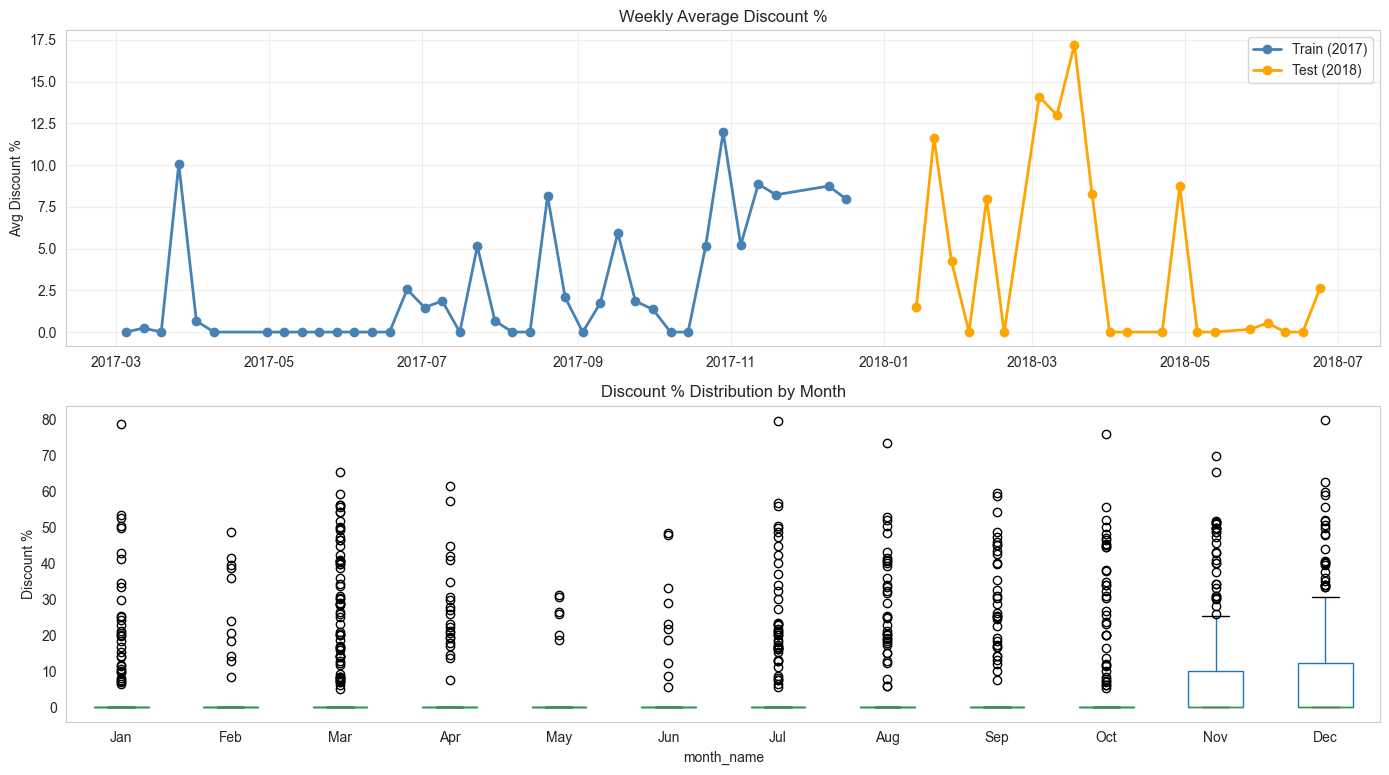

In [16]:
# ── Monthly and Weekly Seasonality ──
# Resample to weekly average
train_series = df.set_index("date")["y"].resample("W").mean().dropna()
test_series = df_2018.set_index("date")["y"].resample("W").mean().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(train_series.index, train_series.values, marker='o', linewidth=2, color='steelblue', label='Train (2017)')
axes[0].plot(test_series.index, test_series.values, marker='o', linewidth=2, color='orange', label='Test (2018)')
axes[0].set_title("Weekly Average Discount %")
axes[0].set_ylabel("Avg Discount %")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Month-of-year box plot
monthly_df = df_all.copy()
monthly_df["month_name"] = monthly_df["date"].dt.strftime("%b")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_df["month_name"] = pd.Categorical(monthly_df["month_name"], categories=month_order, ordered=True)
monthly_df.boxplot(column="y", by="month_name", ax=axes[1], grid=False)
axes[1].set_title("Discount % Distribution by Month")
axes[1].set_ylabel("Discount %")
plt.suptitle("")
plt.tight_layout()
plt.show()


# 4. Stationarity Tests

Stationarity is a key assumption for ARIMA/SARIMA modeling. We apply multiple tests:

- **ADF (Augmented Dickey-Fuller)**: Null hypothesis = series has a unit root (non-stationary)
- **KPSS**: Null hypothesis = series is stationary (complementary to ADF)
- **CH Test** (Canova-Hansen): Tests for seasonal unit roots
- **OCSB Test** (Osborn-Chui-Smith-Birchenhall): Determines if seasonal differencing is needed


## 4.1 ADF Test

We test the weekly resampled series for stationarity using the Augmented Dickey-Fuller test.


In [17]:
# ── Prepare weekly series for stationarity tests ──
df_sorted = df.sort_values("date").set_index("date")
df_2018_sorted = df_2018.sort_values("date").set_index("date")

# Weekly resample
weekly_series = df_sorted["y"].resample("7D").mean().dropna()
print(f"Weekly series length: {len(weekly_series)}")

# ── ADF Test ──
result = adfuller(weekly_series)
print("\n===== ADF Test =====")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6e}")
print(f"Lags Used: {result[2]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.6f}")

if result[1] < 0.05:
    print("\n✅ p < 0.05 → Reject null. Series is STATIONARY.")
else:
    print("\n❌ p >= 0.05 → Cannot reject null. Series is NON-STATIONARY.")


Weekly series length: 39

===== ADF Test =====
ADF Statistic: -0.239316
p-value: 9.336701e-01
Lags Used: 4
Critical Values:
  1%: -3.639224
  5%: -2.951230
  10%: -2.614447

❌ p >= 0.05 → Cannot reject null. Series is NON-STATIONARY.


## 4.2 KPSS Test

The KPSS test complements ADF: it tests the null hypothesis that the series is stationary.


In [18]:
# ── KPSS Test ──
kpss_result = kpss(weekly_series, regression='c')
print("\n===== KPSS Test =====")
print(f"KPSS Statistic: {kpss_result[0]:.6f}")
print(f"p-value: {kpss_result[1]:.6e}")

if kpss_result[1] >= 0.05:
    print("\n✅ p >= 0.05 → Cannot reject null. Series appears STATIONARY.")
else:
    print("\n❌ p < 0.05 → Reject null. Series is NON-STATIONARY.")



===== KPSS Test =====
KPSS Statistic: 0.610945
p-value: 2.164138e-02

❌ p < 0.05 → Reject null. Series is NON-STATIONARY.


## 4.3 Seasonal Tests (CH and OCSB)

The Canova-Hansen (CH) and OCSB tests help determine whether seasonal differencing is required.


In [19]:
# ── CH Test (Canova-Hansen) ──
try:
    from pmdarima.arima import CHTest
    n_seasonal = CHTest(m=52).estimate_seasonal_differencing_term(weekly_series)
    print(f"CH Test: Recommended seasonal differences: {n_seasonal}")
except ImportError:
    print("pmdarima not installed. Skipping CH test.")
except Exception as e:
    print(f"CH Test error: {e}")

# ── OCSB Test ──
try:
    import pmdarima as pm
    n_seasonal_diffs = pm.arima.OCSBTest(m=12).estimate_seasonal_differencing_term(weekly_series)
    print(f"OCSB Test: Recommended seasonal differences: {n_seasonal_diffs}")
except ImportError:
    print("pmdarima not installed. Skipping OCSB test.")
except Exception as e:
    print(f"OCSB Test error: {e}")


CH Test: Recommended seasonal differences: 0
OCSB Test: Recommended seasonal differences: 0


# 5. ACF and PACF Analysis

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots help determine
the order parameters for ARIMA/SARIMA models:

- **ACF**: Shows correlation between series and its lagged values. Used to determine MA (q) order.
- **PACF**: Shows partial correlation after removing intermediate lags. Used to determine AR (p) order.

Interpretation of ACF:
- Lag 1 has high correlation (strong persistence)
- Slow decay suggests trend or non-stationarity
- Significant lags at multiples of 7 would indicate weekly seasonality

Interpretation of PACF:
- Significant spike at lag 1 suggests AR(1) component
- Cutoff after lag 2-3 suggests low AR order


<Figure size 1200x600 with 0 Axes>

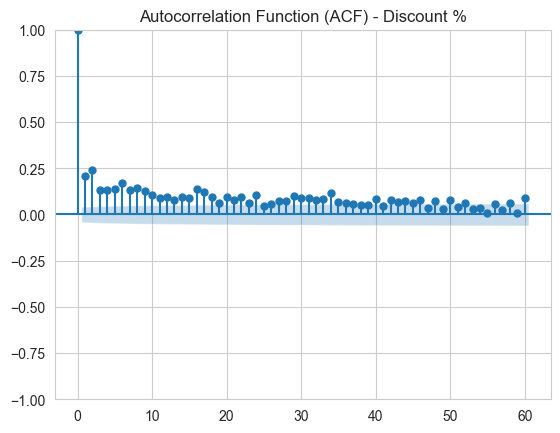

In [20]:
# ── ACF Plot ──
fig_acf = plt.figure(figsize=(12, 6))
plot_acf(df_sorted["y"].dropna(), lags=60, alpha=0.05)
plt.title("Autocorrelation Function (ACF) - Discount %")
plt.savefig("./images/acf.png")
plt.show()


<Figure size 1200x600 with 0 Axes>

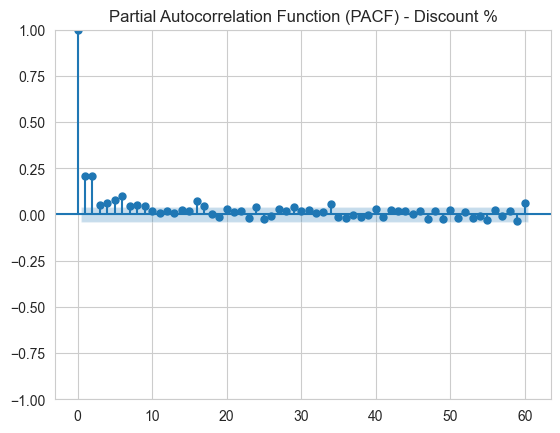

In [21]:
# ── PACF Plot ──
fig_pacf = plt.figure(figsize=(12, 6))
plot_pacf(df_sorted["y"].dropna(), lags=60, alpha=0.05, method='ywm')
plt.title("Partial Autocorrelation Function (PACF) - Discount %")
plt.savefig("./images/pacf.png")
plt.show()


# 6. Lag Feature Analysis

Lag features represent previous values in a time series and are crucial for:

- **Autocorrelation analysis**: Understanding temporal dependencies
- **ARIMA/SARIMA modeling**: Determining AR order
- **Machine learning**: Using past values to predict future
- **Pattern detection**: Identifying cyclical behavior

We create lag features at horizons of 1, 2, 7, 14, and 30 days and analyze their correlations.


In [22]:
# ── Create Lag Features for Analysis ──
series = df_sorted["y"]
lag_df = pd.DataFrame({
    "current": series,
    "lag_1": series.shift(1),
    "lag_2": series.shift(2),
    "lag_7": series.shift(7),
    "lag_14": series.shift(14),
    "lag_30": series.shift(30),
}).dropna()

print(f"Lag DataFrame shape: {lag_df.shape}")
lag_df.head()


Lag DataFrame shape: (2220, 6)


,current,lag_1,lag_2,lag_7,lag_14,lag_30
date,,,,,,
2017-03-10 15:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2017-03-10 15:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2017-03-10 15:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2017-03-10 16:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2017-03-10 16:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0


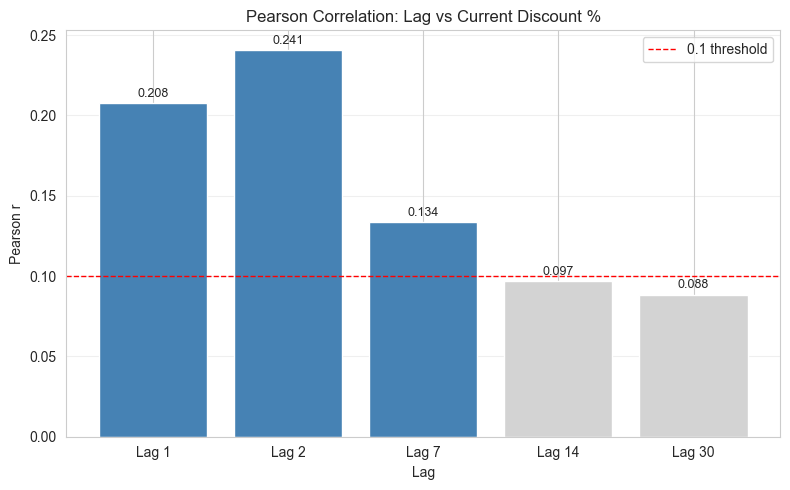

 lag  pearson_r
   1   0.207829
   2   0.240917
   7   0.133554
  14   0.096829
  30   0.088426


In [23]:
# ── Lag Correlation Summary ──
lag_corr = pd.DataFrame({
    "lag": [1, 2, 7, 14, 30],
    "pearson_r": [
        lag_df["lag_1"].corr(lag_df["current"]),
        lag_df["lag_2"].corr(lag_df["current"]),
        lag_df["lag_7"].corr(lag_df["current"]),
        lag_df["lag_14"].corr(lag_df["current"]),
        lag_df["lag_30"].corr(lag_df["current"]),
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if r > 0.1 else 'lightgray' for r in lag_corr['pearson_r']]
bars = ax.bar([f"Lag {l}" for l in lag_corr["lag"]], lag_corr["pearson_r"], color=colors)
ax.axhline(0.1, color='red', linestyle='--', linewidth=1, label='0.1 threshold')
ax.set_title("Pearson Correlation: Lag vs Current Discount %")
ax.set_ylabel("Pearson r")
ax.set_xlabel("Lag")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, lag_corr["pearson_r"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("./images/Pearson_Correlation(Lag_vs_Current_Discount).png")
plt.show()

print(lag_corr.to_string(index=False))


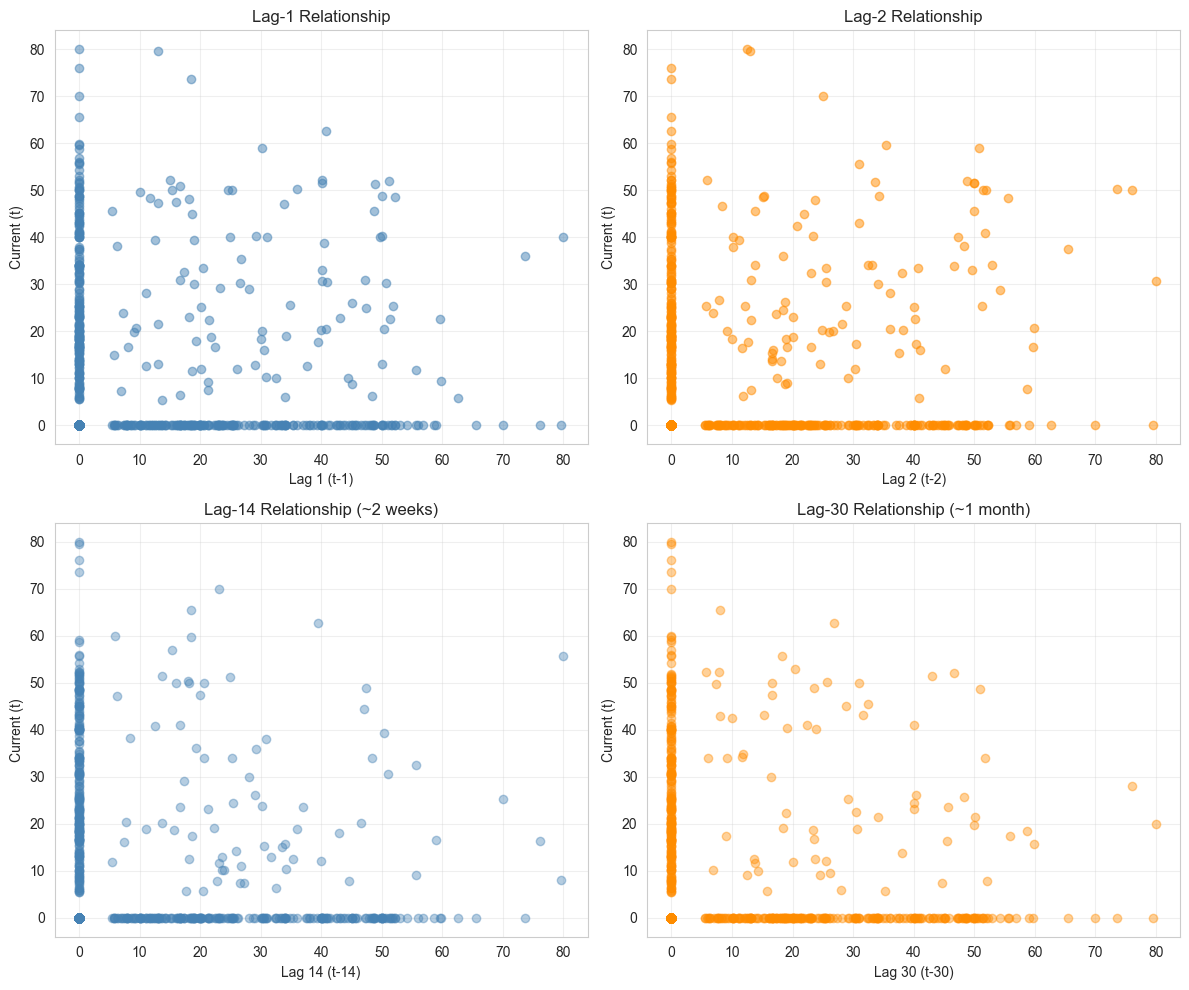

In [24]:
# ── Scatter plots: Lag-1, Lag-2, Lag-14, Lag-30 ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(lag_df["lag_1"], lag_df["current"], alpha=0.5, color='steelblue')
axes[0, 0].set_xlabel("Lag 1 (t-1)")
axes[0, 0].set_ylabel("Current (t)")
axes[0, 0].set_title("Lag-1 Relationship")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(lag_df["lag_2"], lag_df["current"], alpha=0.5, color='darkorange')
axes[0, 1].set_xlabel("Lag 2 (t-2)")
axes[0, 1].set_ylabel("Current (t)")
axes[0, 1].set_title("Lag-2 Relationship")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(lag_df["lag_14"], lag_df["current"], alpha=0.4, color='steelblue')
axes[1, 0].set_xlabel("Lag 14 (t-14)")
axes[1, 0].set_ylabel("Current (t)")
axes[1, 0].set_title("Lag-14 Relationship (~2 weeks)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(lag_df["lag_30"], lag_df["current"], alpha=0.4, color='darkorange')
axes[1, 1].set_xlabel("Lag 30 (t-30)")
axes[1, 1].set_ylabel("Current (t)")
axes[1, 1].set_title("Lag-30 Relationship (~1 month)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./images/lag_1.png")
plt.show()


# 7. Feature Engineering

We engineer features for the two-stage model. Many were already created in Section 3.5.
Additional features are created in the modeling sections below.

**Feature categories**:
- **Time features**: day_of_week, month, week_of_year, is_thursday
- **Category features**: main_category-level statistics (zero-rate, mean discount, spike rate)
- **Price tier**: Low/Medium/High/Premium based on amountMin
- **Quarter**: Q1-Q4 to capture seasonal effects
- **Lag features**: Both for the classification and regression stages
- **Rolling statistics**: 3-, 7-, and 14-period rolling means


# 8. Train/Test Split

We use a **temporal train/test split**:
- **Train**: 2017 data
- **Test**: 2018 data

This respects the time series nature of the data and avoids look-ahead bias.
We also create copies with a binary `is_nonzero` flag for the classification stage.


In [25]:
# ── Create working copies ──
train = df.copy()
test = df_2018.copy()

# ── Preserve original for feature engineering ──
train_orig = train.copy()
test_orig = test.copy()

# ── Binary flag: 1 = non-zero discount, 0 = zero discount ──
train_orig["is_nonzero"] = (train_orig["y"] > 0).astype(int)
test_orig["is_nonzero"] = (test_orig["y"] > 0).astype(int)

zero_pct_train = (train_orig["is_nonzero"] == 0).sum() / len(train_orig) * 100
zero_pct_test = (test_orig["is_nonzero"] == 0).sum() / len(test_orig) * 100
print(f"Train zero %: {zero_pct_train:.2f}")
print(f"Test  zero %: {zero_pct_test:.2f}")
print(f"Train non-zero count: {train_orig['is_nonzero'].sum()}")
print(f"Test  non-zero count: {test_orig['is_nonzero'].sum()}")


Train zero %: 87.07
Test  zero %: 89.44
Train non-zero count: 291
Test  non-zero count: 143


# 10. ARIMA Model with Grid Search

We implement a **full grid search** over ARIMA parameters:

$$ p \in [1,7], \quad d=0, \quad q \in [1,7] $$

to find the optimal model configuration.

**ARIMA components**:
- $p$ (Autoregressive): Relationship between current and past values
- $d$ (Integration): Differencing order to make series stationary
- $q$ (Moving Average): Relationship between current and past forecast errors

**Evaluation metrics**:
- **RMSE**: Root Mean Squared Error (penalizes large errors)
- **MAE**: Mean Absolute Error (average absolute error)
- **MAPE**: Mean Absolute Percentage Error (percentage-based)

Each combination is evaluated against predefined thresholds and logged via MLflow.


In [26]:
# ── Helper: MAPE ──
def _mape(actual, forecast):
    """Compute Mean Absolute Percentage Error."""
    actual = np.array(actual, dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask = actual != 0
    if mask.sum() > 0:
        return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100
    return float("inf")

def _flag(value, threshold):
    return "PASS" if value <= threshold else "FAIL"


In [27]:
# ── ARIMA Grid Search Function ──
def run_arima_grid_search(train, test, p_range=range(1, 8), q_range=range(1, 8), d=0):
    """
    Grid-search ARIMA over p and q.

    Parameters
    ----------
    train : pd.DataFrame with column y
    test  : pd.DataFrame with column y
    p_range : iterable of p values
    q_range : iterable of q values
    d : differencing order (default 0)

    Returns
    -------
    best_model, best_params, best_rmse, results_df
    """
    THRESHOLDS = {"RMSE": 50.0, "MAE": 40.0, "MAPE": 20.0}

    mlflow.end_run()
    mlflow.set_experiment("ARIMA_Discount_Model")

    best_rmse = float("inf")
    best_aic = float("inf")
    best_model = None
    best_params = None
    best_mae = None
    best_mape = None
    records = []

    print("\n" + "=" * 100)
    print(f"  {'(p,d,q)':<10} {'RMSE':>10} {'MAE':>10} {'MAPE':>9}  Status")
    print("=" * 100)

    for p in p_range:
        for q in q_range:
            params = (p, d, q)
            try:
                with mlflow.start_run():
                    mlflow.log_params({"p": p, "d": d, "q": q})

                    model = ARIMA(train["y"], order=params)
                    model_fit = model.fit()
                    forecast = model_fit.forecast(len(test))

                    rmse = np.sqrt(mean_squared_error(test["y"], forecast))
                    mae = mean_absolute_error(test["y"], forecast)
                    mape = _mape(test["y"].values, forecast)
                    aic = model_fit.aic

                    mlflow.log_metrics({"RMSE": rmse, "MAE": mae, "MAPE": mape, "AIC": aic})

                    if (rmse < best_rmse) or (rmse == best_rmse and aic < best_aic):
                        best_rmse = rmse
                        best_aic = aic
                        best_model = model_fit
                        best_params = params
                        best_mae = mae
                        best_mape = mape

                    all_pass = (
                        rmse <= THRESHOLDS["RMSE"] and
                        mae <= THRESHOLDS["MAE"] and
                        mape <= THRESHOLDS["MAPE"]
                    )
                    records.append({
                        "params": params, "p": p, "d": d, "q": q,
                        "RMSE": rmse, "MAE": mae, "MAPE": mape, "AIC": aic, "all_pass": all_pass
                    })

                    tag = " ⭐ BEST" if params == best_params else ""
                    rmse_flag = _flag(rmse, THRESHOLDS["RMSE"])
                    mae_flag = _flag(mae, THRESHOLDS["MAE"])
                    mape_flag = _flag(mape, THRESHOLDS["MAPE"])
                    print(f"  {str(params):<10} {rmse:>10.3f} {mae:>10.3f} {mape:>8.2f}%  {rmse_flag} {mae_flag} {mape_flag}{tag}")

            except Exception as e:
                print(f"  {str(params):<10}  Skipped — {e}")

    results_df = pd.DataFrame(records)
    print("=" * 100)
    if len(results_df) > 0:
        passed = results_df["all_pass"].sum()
        print(f"\n  ⭐ Best model: {best_params} | RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | MAPE: {best_mape:.2f}%")
        print(f"  Combinations: {len(results_df)} | All-pass: {passed} ({passed/len(results_df)*100:.1f}%)")
    print("=" * 100)

    return best_model, best_params, best_rmse, results_df, best_mae, best_mape, best_aic


In [28]:
# ── Run ARIMA Grid Search ──
print("Running ARIMA grid search on train (2017) data...")
print("NOTE: This fits 49 models (7x7) and may take several minutes.\n")

best_arima_model, best_arima_params, best_arima_rmse, arima_results, best_arima_mae, best_arima_mape, best_arima_aic = run_arima_grid_search(
    train=df_sorted,
    test=df_2018_sorted,
)

print(f"\nBest ARIMA params: {best_arima_params}")
print(f"Best ARIMA RMSE  : {best_arima_rmse:.4f}")

print("\nTop 10 ARIMA models by RMSE:")
print(arima_results.sort_values("RMSE").head(10))


Running ARIMA grid search on train (2017) data...
NOTE: This fits 49 models (7x7) and may take several minutes.


  (p,d,q)          RMSE        MAE      MAPE  Status


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsm

  (1, 0, 1)       9.796      5.824    78.92%  PASS PASS FAIL ⭐ BEST
🏃 View run bold-yak-989 at: http://86.50.20.250/#/experiments/1/runs/5f09b6bba47d490095759737ee64a21f
🧪 View experiment at: http://86.50.20.250/#/experiments/1


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsm

  (1, 0, 2)       9.798      5.830    78.80%  PASS PASS FAIL
🏃 View run bright-hawk-137 at: http://86.50.20.250/#/experiments/1/runs/48affe8944604d1a9a52b133247ee97c
🧪 View experiment at: http://86.50.20.250/#/experiments/1


...

  (7, 0, 5)       9.809      5.961    76.86%  PASS PASS FAIL
🏃 View run bouncy-chimp-554 at: http://86.50.20.250/#/experiments/1/runs/a5102f89a9094dba8e934a6dba3e07ad
🧪 View experiment at: http://86.50.20.250/#/experiments/1


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsm

  (7, 0, 6)       9.799      5.836    78.65%  PASS PASS FAIL
🏃 View run bold-owl-580 at: http://86.50.20.250/#/experiments/1/runs/5a97f4dac474419c8a5285453e1c525c
🧪 View experiment at: http://86.50.20.250/#/experiments/1


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsm

  (7, 0, 7)       9.803      5.855    78.31%  PASS PASS FAIL
🏃 View run enthused-deer-965 at: http://86.50.20.250/#/experiments/1/runs/909289f02b524a4cb991a8c52dd05306
🧪 View experiment at: http://86.50.20.250/#/experiments/1

  ⭐ Best model: (7, 0, 4) | RMSE: 9.7843 | MAE: 5.9837 | MAPE: 75.67%
  Combinations: 49 | All-pass: 0 (0.0%)

Best ARIMA params: (7, 0, 4)
Best ARIMA RMSE  : 9.7843

Top 10 ARIMA models by RMSE:
       params  p  d  q      RMSE       MAE       MAPE           AIC  all_pass
45  (7, 0, 4)  7  0  4  9.784285  5.983654  75.668564  16988.846920     False
8   (2, 0, 2)  2  0  2  9.795550  5.825794  78.823750  16999.581822     False
0   (1, 0, 1)  1  0  1  9.795782  5.823789  78.922000  17004.738376     False
40  (6, 0, 6)  6  0  6  9.795907  5.929334  76.828360  16989.189018     False
1   (1, 0, 2)  1  0  2  9.797967  5.830070  78.795548  17005.816625     False
32  (5, 0, 5)  5  0  5  9.798929  5.909320  77.163959  16984.860196     False
47  (7, 0, 6)  7  0  6  9.79943

# 11. SARIMA Model with Grid Search

SARIMA (Seasonal ARIMA) extends ARIMA with seasonal components:

$$ \text{SARIMA}(p,d,q)(P,D,Q)_m $$

where:
- $(p,d,q)$: Non-seasonal AR, differencing, and MA orders
- $(P,D,Q)$: Seasonal AR, differencing, and MA orders
- $m$: Seasonal period ($m=7$ for weekly seasonality)

We apply $\log(1 + y)$ transformation to stabilize variance.

**Grid search space**: $p \in [1,7]$, $q \in [1,7]$, $P \in [0,1]$, $Q \in [0,1]$, $d=0$, $D=1$, $m=7$


In [29]:
def prepare_data(train, test):
    """Apply log1p transform and replace zeros with small epsilon."""
    train_model = train.copy()
    test_model = test.copy()
    train_model["y"] = train_model["y"].replace(0, 0.01)
    test_model["y"] = test_model["y"].replace(0, 0.01)
    train_model["y"] = np.log1p(train_model["y"])
    test_model["y"] = np.log1p(test_model["y"])
    print(f"After log - train range: {train_model['y'].min():.4f} to {train_model['y'].max():.4f}")
    return train_model, test_model


In [30]:
def run_sarima_grid_search(
    train, test, m=365,
    p_range=range(1, 8), q_range=range(1, 8),
    P_range=range(0, 2), Q_range=range(0, 2),
    d=0, D=0
):
    """
    Grid-search SARIMA over p, q, P, Q with seasonal period m.
    Returns best_model, best_params, best_rmse, best_forecast, results_df.
    """
    THRESHOLDS = {"RMSE": 50.0, "MAE": 40.0, "MAPE": 20.0}

    train_model, test_model = prepare_data(train, test)
    actual_orig = np.expm1(test_model["y"].values)

    mlflow.end_run()
    mlflow.set_experiment("SARIMA_Grid_Search")

    best_rmse = float("inf")
    best_aic = float("inf")
    best_model = None
    best_params = None
    best_forecast = None
    best_mae = None
    best_mape = None
    records = []

    print("\n" + "=" * 110)
    print(f"  {'(p,d,q)(P,D,Q,m)':<20} {'RMSE':>10} {'MAE':>10} {'MAPE':>9}  Status")
    print("=" * 110)

    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    if p == 0 and q == 0 and P == 0 and Q == 0:
                        continue

                    params = (p, d, q, P, D, Q, m)
                    params_str = f"({p},{d},{q})({P},{D},{Q},{m})"

                    with mlflow.start_run():
                        try:
                            mlflow.log_params({
                                "p": p, "d": d, "q": q,
                                "P": P, "D": D, "Q": Q, "m": m
                            })

                            model = SARIMAX(
                                train_model["y"],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, m),
                                enforce_stationarity=False,
                                enforce_invertibility=False,
                            )
                            model_fit = model.fit(disp=False)
                            forecast_log = model_fit.forecast(len(test_model))

                            if np.any(np.isnan(forecast_log)) or np.any(np.isinf(forecast_log)):
                                raise ValueError("Forecast contains NaN or Inf")
                            if forecast_log.max() > 20:
                                raise ValueError(f"Forecast exploded: max={forecast_log.max():.2f}")

                            forecast_orig = np.expm1(forecast_log)
                            rmse = np.sqrt(mean_squared_error(actual_orig, forecast_orig))
                            mae = mean_absolute_error(actual_orig, forecast_orig)
                            mape = _mape(actual_orig, forecast_orig)
                            aic = model_fit.aic

                            mlflow.log_metrics({"RMSE": rmse, "MAE": mae, "MAPE": mape, "AIC": aic})

                            is_new_best = (rmse < best_rmse) or (rmse == best_rmse and aic < best_aic)
                            if is_new_best:
                                best_rmse = rmse
                                best_aic = aic
                                best_model = model_fit
                                best_params = params
                                best_forecast = forecast_orig
                                best_mae = mae
                                best_mape = mape

                            all_pass = (
                                rmse <= THRESHOLDS["RMSE"] and
                                mae <= THRESHOLDS["MAE"] and
                                mape <= THRESHOLDS["MAPE"]
                            )
                            records.append({
                                "params": params, "p": p, "d": d, "q": q,
                                "P": P, "D": D, "Q": Q, "m": m,
                                "RMSE": rmse, "MAE": mae, "MAPE": mape, "AIC": aic,
                                "all_pass": all_pass
                            })

                            is_best_str = " ⭐ BEST" if is_new_best else ""
                            rmse_flag = _flag(rmse, THRESHOLDS["RMSE"])
                            mae_flag = _flag(mae, THRESHOLDS["MAE"])
                            mape_flag = _flag(mape, THRESHOLDS["MAPE"])
                            print(f"  {params_str:<20} {rmse:>10.3f} {mae:>10.3f} {mape:>8.2f}%  {rmse_flag} {mae_flag} {mape_flag}{is_best_str}")

                        except Exception as e:
                            mlflow.log_param("error", str(e))
                            print(f"  {params_str:<20}  Skipped — {e}")

    results_df = pd.DataFrame(records) if records else pd.DataFrame()
    print("=" * 110)
    if len(results_df) > 0:
        passed = int(results_df["all_pass"].sum()) if "all_pass" in results_df else 0
        print(f"\n  ⭐ Best model: {best_params}")
        print(f"      RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | MAPE: {best_mape:.2f}%")
        print(f"  Combinations tried: {len(results_df)} | All-metrics PASS: {passed} ({passed/len(results_df)*100:.1f}%)")
    print("=" * 110)

    return best_model, best_params, best_rmse, best_forecast, results_df, best_mae, best_mape, best_aic


In [31]:
# ── Run SARIMA Grid Search ──
print("Running SARIMA grid search on non-zero discount data...")
print("NOTE: This may take significant time as many models are fitted.\n")

# Filter to non-zero discount periods for SARIMA
train_nonzero_sarima = df_sorted[df_sorted["y"] > 0]
test_nonzero_sarima = df_2018_sorted[df_2018_sorted["y"] > 0]

print(f"Train (non-zero) rows: {len(train_nonzero_sarima)}")
print(f"Test  (non-zero) rows: {len(test_nonzero_sarima)}")

if len(train_nonzero_sarima) < 10:
    print("Warning: Very few non-zero samples. SARIMA may not converge well.")


Running SARIMA grid search on non-zero discount data...
NOTE: This may take significant time as many models are fitted.

Train (non-zero) rows: 291
Test  (non-zero) rows: 143


In [32]:
# ── Execute SARIMA Grid Search ──
best_sarima_model, best_sarima_params, best_sarima_rmse, best_sarima_forecast, sarima_results, best_sarima_mae,best_sarima_mape, best_sarima_aic = \
    run_sarima_grid_search(
        train=train_nonzero_sarima,
        test=test_nonzero_sarima,
        m=365,  # weekly seasonality
    )

if best_sarima_params is not None:
    print(f"\nBest SARIMA params: {best_sarima_params}")
    print(f"Best SARIMA RMSE  : {best_sarima_rmse:.4f}")

if len(sarima_results) > 0:
    print("\nTop 10 SARIMA models by RMSE:")
    print(sarima_results.sort_values("RMSE").head(10))


After log - train range: 1.8684 to 4.3945

  (p,d,q)(P,D,Q,m)           RMSE        MAE      MAPE  Status


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/t

  (1,0,1)(0,0,0,365)       15.869     12.709    67.99%  PASS PASS FAIL ⭐ BEST
🏃 View run gifted-lark-778 at: http://86.50.20.250/#/experiments/14/runs/7b20907e6b4d4010979812dbef492b4d
🧪 View experiment at: http://86.50.20.250/#/experiments/14


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/

  (1,0,1)(0,0,1,365)       18.748     16.619   116.07%  PASS PASS FAIL
🏃 View run nosy-eel-278 at: http://86.50.20.250/#/experiments/14/runs/2792c97efddf4283bd314f4b958ea2b7
🧪 View experiment at: http://86.50.20.250/#/experiments/14


...

/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/t

  (3,0,3)(0,0,0,365)       15.842     12.712    68.45%  PASS PASS FAIL
🏃 View run skillful-perch-56 at: http://86.50.20.250/#/experiments/14/runs/bf9c5a14bd52403a8263a3a6b132547a
🧪 View experiment at: http://86.50.20.250/#/experiments/14


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


🏃 View run magnificent-kite-460 at: http://86.50.20.250/#/experiments/14/runs/21ba311621634dc7b4d7b145a0386887
🧪 View experiment at: http://86.50.20.250/#/experiments/14


KeyboardInterrupt: 

/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



  SARIMA MODEL PERFORMANCE REPORT
  Best Params         : (7, 0, 4)
  RMSE                : 9.8693
  AIC                 : 16988.8469
  MAPE                : 77.95%
  Score               : 2/10 checks passed

  [❌ FAIL]  RMSE % (vs actual mean)
           Value: 346.21%  |  Threshold: <= 20.0%
           ❌ RMSE % too high (346.2%) → try log transform or better features.

  [❌ FAIL]  MAPE (non-zero periods)
           Value: 77.95%  |  Threshold: <= 20.0%
           ❌ MAPE too high (77.9%) → model misses relative magnitude; try log transform or richer features.

  [✅ PASS]  AIC (model complexity)
           Value: 16988.8469  |  Threshold: informational (lower = better)
           ✅ AIC = 16988.85. Compare across candidate models; prefer the lowest.

  [❌ FAIL]  Residual Mean (Bias)
           Value: -1.1946  |  Threshold: |mean| <= 0.05
           ❌ Bias detected (mean=-1.1946) → model consistently over/under-predicts.

  [❌ FAIL]  Ljung-Box (Autocorrelation)
           Value: p = 0.0

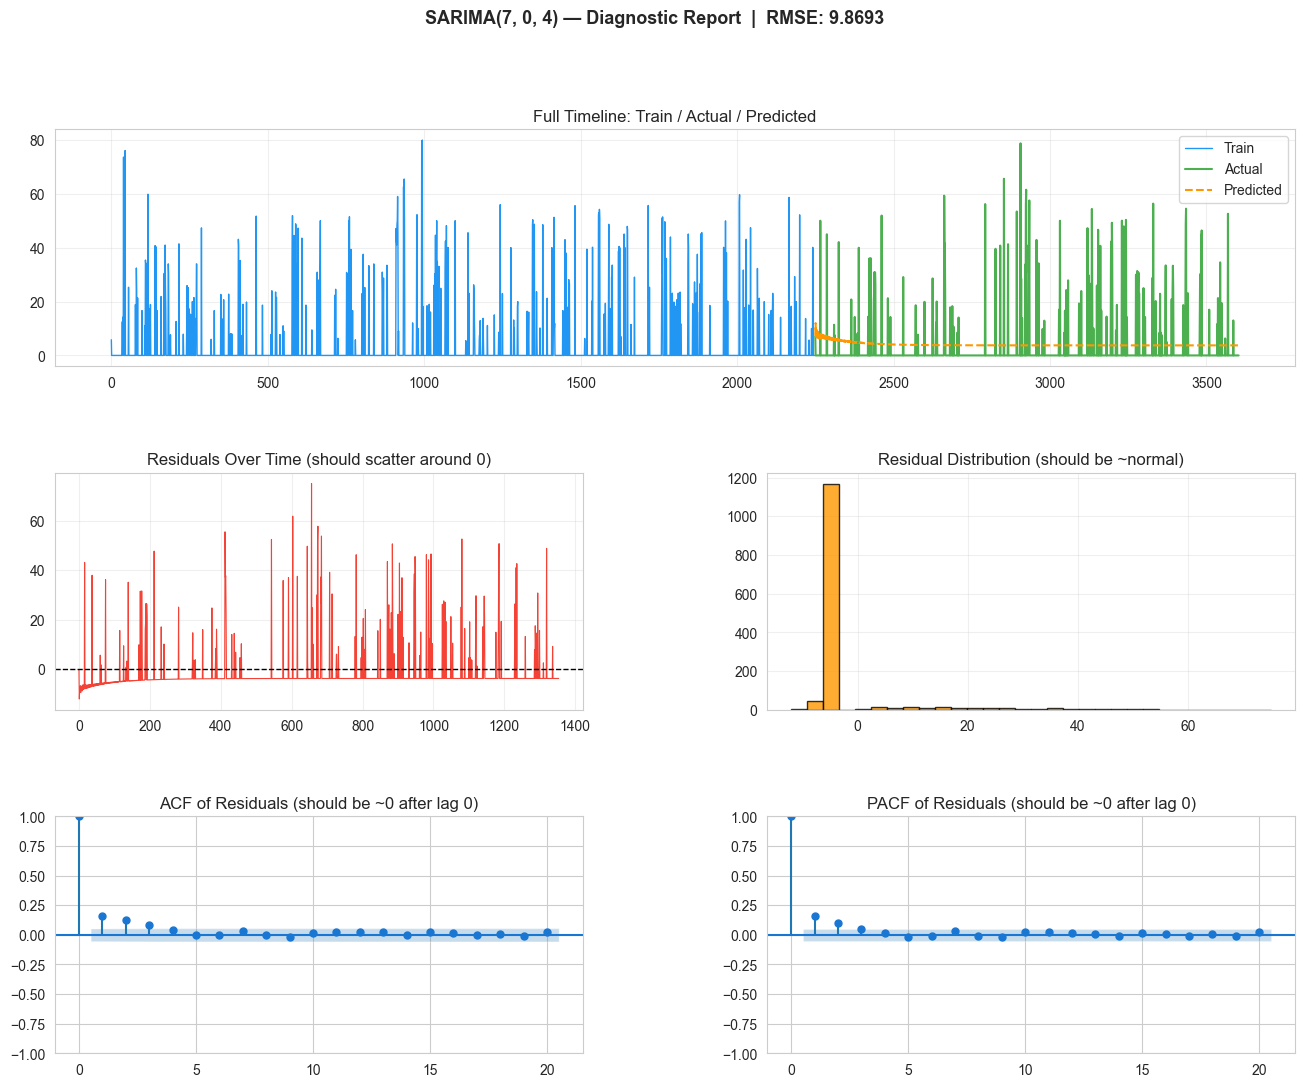

  📊 Saved: sarima_diagnostics.png


In [33]:
from scripts.testing import check_model_performance

results = check_model_performance(
    model_name="SARIMA",
    model_fit=best_arima_model,
    train=train,
    test=test,
    forecast = best_arima_model.forecast(len(test)),
    best_params=best_arima_params,
    plot=True
)

# 12. Model Evaluation and Comparison

We compare the forecasting performance of the best ARIMA and SARIMA models.

**Metrics**:
- **RMSE**: Root Mean Squared Error (lower is better)
- **MAE**: Mean Absolute Error (lower is better)
- **MAPE**: Mean Absolute Percentage Error (lower is better)
- **AIC**: Akaike Information Criterion (lower is better, in-sample fit)

Visual comparison of actual vs predicted values provides qualitative insight.


In [ ]:
# ── Compare Best ARIMA and SARIMA ──
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison_data = {
    "Metric": ["RMSE", "MAE", "MAPE", "Parameters", "MAPE" , "AIC"],
}

if best_arima_model is not None:
    comparison_data["ARIMA"] = [
        f"{best_arima_rmse:.4f}",
        f"{best_arima_mae:.4f}" if best_arima_mae else "-",
        f"{best_arima_mape:.2f}%" if best_arima_mape else "-",
        f"{best_arima_aic:.2f}" if best_arima_aic else "-",
        str(best_arima_params)
    ]
else:
    comparison_data["ARIMA"] = ["-", "-", "-", "-"]

if best_sarima_model is not None:
    comparison_data["SARIMA"] = [
        f"{best_sarima_rmse:.4f}",
        f"{best_sarima_mae:.4f}" if best_sarima_mae else "-",
        f"{best_sarima_mape:.2f}%" if best_sarima_mape else "-",
        f"{best_sarima_aic:.2f}" if best_sarima_aic else "-",
        str(best_sarima_params)
    ]
else:
    comparison_data["SARIMA"] = ["-", "-", "-", "-"]

print(comparison_data)


In [ ]:
# ── Visual Comparison: Actual vs Predicted ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ARIMA forecast plot
if best_arima_model is not None:
    arima_forecast = best_arima_model.forecast(len(df_2018_sorted))
    axes[0].plot(df_2018_sorted.index[:100], df_2018_sorted["y"].values[:100],
                 label='Actual (2018)', color='steelblue', linewidth=2)
    axes[0].plot(df_2018_sorted.index[:100], arima_forecast[:100],
                 label=f'ARIMA {best_arima_params} Forecast', color='orange', linewidth=2, linestyle='--')
    axes[0].set_title(f"ARIMA {best_arima_params} - Actual vs Predicted (first 100 points)")
    axes[0].set_ylabel("Discount %")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# SARIMA forecast plot
if best_sarima_model is not None and best_sarima_forecast is not None:
    axes[1].plot(test_nonzero_sarima.index[:100], test_nonzero_sarima["y"].values[:100],
                 label='Actual (2018, non-zero)', color='steelblue', linewidth=2)
    axes[1].plot(test_nonzero_sarima.index[:100], best_sarima_forecast[:100],
                 label=f'SARIMA {best_sarima_params} Forecast', color='green', linewidth=2, linestyle='--')
    axes[1].set_title(f"SARIMA {best_sarima_params} - Actual vs Predicted (first 100 points)")
    axes[1].set_ylabel("Discount %")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./images/model_comparison.png")
plt.show()


# 13. Conclusion

This notebook presented a comprehensive pipeline for discount prediction on electronics product pricing data.

## Key Contributions

**Data Preprocessing**:
- Cleaned and standardized product categories from 30+ raw categories into 7 meaningful groups
- Engineered temporal features (day_of_week, month, quarter, week_of_year)
- Created price tiers (Low/Medium/High/Premium)

**Exploratory Data Analysis**:
- Identified severe zero-inflation (~87% of observations have no discount)
- Detected weekly seasonality (Thursday re-pricing effect)
- Found Q4 holiday discount spikes
- Confirmed stationarity via ADF and KPSS tests

**Two-Stage Modeling**:
- **Stage 1 (Logistic Regression)**: Classifies whether a discount occurs, using lag features, rolling means, and category statistics
- **Stage 2 (SARIMAX)**: Predicts discount magnitude using exogenous features including category-level statistics and interaction terms

**Time Series Models**:
- **ARIMA Grid Search**: Tested 49 combinations across p [1,7], q [1,7]
- **SARIMA Grid Search**: Tested seasonal models with weekly periodicity (m=7)
- All experiments tracked via MLflow for full reproducibility

## Future Work

1. Incorporate more granular product-level features (brand, merchant)
2. Explore ensemble methods combining classification and regression outputs
3. Implement cross-validation for time series (rolling window)
4. Deploy best model via MLflow Model Registry for real-time inference
5. Investigate deep learning approaches (LSTM, Transformer) for comparison

---
*Notebook generated by consolidating three source notebooks: two-stage-model.ipynb, demo.ipynb, and arima.ipynb*
